# RT-DETRv2-X Pill Detection Competition Notebook

이 노트북은 `mAP@[0.75:0.95]` 평가 대회를 기준으로 만든 **RT-DETRv2-X detector 학습 + 추론 + submission.csv 생성** 템플릿입니다.

핵심 흐름:

```text
train.csv
  ↓
COCO detection format 변환
  ↓
RT-DETRv2-X fine-tuning
  ↓
validation mAP@[0.75:0.95] 확인
  ↓
test inference
  ↓
submission.csv
```

> 평가 IoU threshold가 높기 때문에, confidence보다 **bbox localization 품질**이 특히 중요합니다.

## 0. 사용 전 체크

아래 3가지만 먼저 맞추면 됩니다.

1. `COMPETITION_INPUT_DIR`를 Kaggle input 경로로 수정
2. `TRAIN_CSV_NAME`, `TRAIN_IMAGE_DIR_NAME`, `TEST_IMAGE_DIR_NAME` 확인
3. GPU 메모리 부족 시 `MODEL_SIZE='l'` 또는 `TOTAL_BATCH_SIZE=2`로 낮추기

RT-DETRv2-X는 강한 detector지만 VRAM을 꽤 먹습니다. 작은 숟가락으로 용을 퍼먹는 기분이 날 수 있으니, OOM이 나면 L 모델로 내려가면 됩니다. 🐉

In [38]:
# =========================
# Notebook Parameters
# =========================
import os
import subprocess
import sys
from pathlib import Path

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

def find_project_dir(start: Path | None = None):
    start = Path(start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "sprint_ai_project1_data").exists():
            return candidate
    raise FileNotFoundError(f"Could not find project root from {start}")

PROJECT_DIR = find_project_dir()
os.chdir(PROJECT_DIR)
COMPETITION_INPUT_DIR = PROJECT_DIR / "sprint_ai_project1_data"
CORRECTIONS_PATH = PROJECT_DIR / "corrections.json"

TRAIN_CSV_NAME = "train.csv"
TRAIN_IMAGE_DIR_NAME = "train_images"
TEST_IMAGE_DIR_NAME = "test_images"
TRAIN_ANNOTATION_DIR_NAME = "train_annotations"

# RT-DETRv2 model size: "x" = RT-DETRv2-X, "l" = RT-DETRv2-L fallback
MODEL_SIZE = "x"

# 고 IoU 대회라 640 baseline 후 800/960도 실험 추천
IMAGE_SIZE = 640

# 대회 조건상 이미지당 최대 객체 수가 4개라면 4
MAX_DET_PER_IMAGE = 4

# mAP는 ranking이 중요하므로 threshold는 낮게 두고 top-k로 제한
SCORE_THR = 0.001

VAL_SIZE = 0.15
RANDOM_SEED = 42

EPOCHS = 50
TOTAL_BATCH_SIZE = 4
NUM_WORKERS = 0

# processor: "mps" for Apple Silicon, "cuda" for NVIDIA, "cpu", or "auto"
PROCESSOR = "mps"
USE_AMP = False

WORK_DIR = PROJECT_DIR / "working"
DATA_WORK_DIR = WORK_DIR / "pill_coco"
REPO_DIR = WORK_DIR / "RT-DETR"
RTDETRV2_DIR = REPO_DIR / "rtdetrv2_pytorch"

print("COMPETITION_INPUT_DIR:", COMPETITION_INPUT_DIR)
print("WORK_DIR:", WORK_DIR)
print("PROCESSOR:", PROCESSOR)
print("MODEL_SIZE:", MODEL_SIZE)
print("IMAGE_SIZE:", IMAGE_SIZE)

COMPETITION_INPUT_DIR: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/sprint_ai_project1_data
WORK_DIR: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working
PROCESSOR: mps
MODEL_SIZE: x
IMAGE_SIZE: 640


## 1. Install & Clone RT-DETRv2

Kaggle Notebook에서 실행하는 기준입니다.  
이미 repo가 있으면 clone은 건너뜁니다.

In [39]:
import os
from pathlib import Path

WORK_DIR.mkdir(parents=True, exist_ok=True)

if not RTDETRV2_DIR.exists():
    !git clone https://github.com/lyuwenyu/RT-DETR.git {REPO_DIR}
else:
    print("RT-DETR repo already exists:", RTDETRV2_DIR)

os.chdir(RTDETRV2_DIR)
print("cwd:", Path.cwd())

# Mac/MPS 학습에 필요한 패키지만 설치합니다. RT-DETR requirements의 onnxruntime-gpu는 Mac에서 설치되지 않습니다.
install_packages = [
    "tensorboard",
    "faster-coco-eval",
    "pycocotools",
    "opencv-python-headless",
    "pandas",
    "pillow",
    "tqdm",
    "scikit-learn",
    "matplotlib",
    "PyYAML",
    "scipy",
    "timm",
]
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *install_packages])

RT-DETR repo already exists: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch
cwd: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


0

## 2. Imports & Reproducibility

In [40]:
import os
import subprocess
import subprocess
import sys
import json
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(RANDOM_SEED)

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
print("mps available:", torch.backends.mps.is_available() if hasattr(torch.backends, "mps") else False)

def resolve_device(processor="auto"):
    processor = str(processor).lower()
    has_mps = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    if processor == "mps" and has_mps:
        return "mps"
    if processor == "cuda" and torch.cuda.is_available():
        return "cuda"
    if processor == "cpu":
        return "cpu"
    if processor == "auto":
        if has_mps:
            return "mps"
        if torch.cuda.is_available():
            return "cuda"
    print(f"requested processor={processor!r} is not available; falling back to cpu")
    return "cpu"

TRAIN_DEVICE = resolve_device(PROCESSOR)
print("train/inference device:", TRAIN_DEVICE)

torch: 2.12.0
cuda available: False
mps available: True
train/inference device: mps


## 3. Locate Data

대회마다 폴더명이 다를 수 있어서, 지정 경로가 틀렸을 때 후보를 보여주도록 만들었습니다.

In [41]:
def list_input_tree(root: Path, max_depth=2, max_items=80):
    root = Path(root)
    rows = []
    for p in sorted(root.rglob("*")):
        rel = p.relative_to(root)
        if len(rel.parts) <= max_depth:
            rows.append(str(rel) + ("/" if p.is_dir() else ""))
        if len(rows) >= max_items:
            break
    return rows

if not COMPETITION_INPUT_DIR.exists():
    print("❌ COMPETITION_INPUT_DIR not found.")
    print("Available project items:")
    for p in PROJECT_DIR.glob("*"):
        print(" -", p)
else:
    print("✅ input dir exists:", COMPETITION_INPUT_DIR)
    print("\nPreview:")
    for item in list_input_tree(COMPETITION_INPUT_DIR):
        print(" -", item)

✅ input dir exists: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/sprint_ai_project1_data

Preview:
 - test_images/
 - test_images/1.png
 - test_images/10.png
 - test_images/100.png
 - test_images/1003.png
 - test_images/1004.png
 - test_images/1005.png
 - test_images/1006.png
 - test_images/1007.png
 - test_images/1009.png
 - test_images/1010.png
 - test_images/1012.png
 - test_images/1013.png
 - test_images/1014.png
 - test_images/1015.png
 - test_images/1016.png
 - test_images/1018.png
 - test_images/1019.png
 - test_images/102.png
 - test_images/1020.png
 - test_images/1022.png
 - test_images/1023.png
 - test_images/1025.png
 - test_images/1026.png
 - test_images/1027.png
 - test_images/1028.png
 - test_images/1029.png
 - test_images/1030.png
 - test_images/1034.png
 - test_images/1039.png
 - test_images/104.png
 - test_images/1041.png
 - test_images/1043.png
 - test_images/1044.png
 - test_images/1045.png
 - test_images/1046.png
 - test_images/1047.png
 - test_images/1050

In [42]:
TRAIN_CSV = COMPETITION_INPUT_DIR / TRAIN_CSV_NAME
TRAIN_IMG_DIR = COMPETITION_INPUT_DIR / TRAIN_IMAGE_DIR_NAME
TEST_IMG_DIR = COMPETITION_INPUT_DIR / TEST_IMAGE_DIR_NAME
TRAIN_ANN_DIR = COMPETITION_INPUT_DIR / TRAIN_ANNOTATION_DIR_NAME

# Fallback: 이름이 다르면 csv와 이미지 폴더 후보 자동 탐색
if not TRAIN_CSV.exists() and not TRAIN_ANN_DIR.exists():
    csv_candidates = list(COMPETITION_INPUT_DIR.rglob("*.csv"))
    print("CSV candidates:")
    for p in csv_candidates:
        print(" -", p)
    raise FileNotFoundError(f"TRAIN_CSV not found and TRAIN_ANN_DIR not found: {TRAIN_CSV}, {TRAIN_ANN_DIR}")

if not TRAIN_IMG_DIR.exists():
    print("Image directory candidates:")
    for p in COMPETITION_INPUT_DIR.rglob("*"):
        if p.is_dir() and any(x.suffix.lower() in [".jpg", ".jpeg", ".png"] for x in p.glob("*")):
            print(" -", p)
    raise FileNotFoundError(f"TRAIN_IMG_DIR not found: {TRAIN_IMG_DIR}")

if not TEST_IMG_DIR.exists():
    print("Image directory candidates:")
    for p in COMPETITION_INPUT_DIR.rglob("*"):
        if p.is_dir() and any(x.suffix.lower() in [".jpg", ".jpeg", ".png"] for x in p.glob("*")):
            print(" -", p)
    raise FileNotFoundError(f"TEST_IMG_DIR not found: {TEST_IMG_DIR}")

print("TRAIN_CSV:", TRAIN_CSV)
print("TRAIN_IMG_DIR:", TRAIN_IMG_DIR)
print("TEST_IMG_DIR:", TEST_IMG_DIR)
print("TRAIN_ANN_DIR:", TRAIN_ANN_DIR)

TRAIN_CSV: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/sprint_ai_project1_data/train.csv
TRAIN_IMG_DIR: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/sprint_ai_project1_data/train_images
TEST_IMG_DIR: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/sprint_ai_project1_data/test_images
TRAIN_ANN_DIR: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/sprint_ai_project1_data/train_annotations


## 4. Load & Validate Train CSV

대회 제출 포맷은 아래 컬럼을 요구합니다.

```text
annotation_id, image_id, category_id, bbox_x, bbox_y, bbox_w, bbox_h, score
```

학습용 `train.csv`에 `score`가 있으면 무시합니다.

In [43]:
def build_train_csv_from_json_annotations(annotation_dir: Path, out_csv: Path):
    rows = []
    json_paths = sorted(annotation_dir.rglob("*.json"))
    if not json_paths:
        raise FileNotFoundError(f"No annotation json files under {annotation_dir}")

    for json_path in tqdm(json_paths, desc="read annotations"):
        with open(json_path, "r") as f:
            coco = json.load(f)

        images = coco.get("images", [])
        image_by_id = {int(img["id"]): img for img in images}
        default_image = images[0] if images else {}

        for ann in coco.get("annotations", []):
            image_id = int(ann.get("image_id", default_image.get("id")))
            img = image_by_id.get(image_id, default_image)
            bbox_x, bbox_y, bbox_w, bbox_h = ann["bbox"]
            rows.append({
                "annotation_id": int(ann.get("id", len(rows) + 1)),
                "image_id": image_id,
                "file_name": img.get("file_name") or img.get("imgfile"),
                "category_id": int(ann["category_id"]),
                "bbox_x": bbox_x,
                "bbox_y": bbox_y,
                "bbox_w": bbox_w,
                "bbox_h": bbox_h,
            })

    df_built = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
    df_built["annotation_id"] = np.arange(1, len(df_built) + 1)
    out_csv.parent.mkdir(parents=True, exist_ok=True)
    df_built.to_csv(out_csv, index=False)
    return df_built

def apply_annotation_corrections(df_in: pd.DataFrame, corrections_path: Path):
    df_out = df_in.copy()
    if not corrections_path.exists():
        print("corrections file not found; using raw annotations:", corrections_path)
        return df_out

    with open(corrections_path, "r") as f:
        corrections = json.load(f)

    corrected_count = 0
    for item in corrections.get("bbox_corrections", []):
        ann_id = int(item["ann_id"])
        mask = pd.to_numeric(df_out["annotation_id"], errors="coerce").astype("Int64") == ann_id
        if not mask.any():
            print("warning: correction ann_id not found:", ann_id)
            continue
        x, y, w, h = item["corrected"]
        df_out.loc[mask, ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]] = [x, y, w, h]
        corrected_count += int(mask.sum())

    existing_ann_ids = set(pd.to_numeric(df_out["annotation_id"], errors="coerce").dropna().astype(int))
    additions = []
    for item in corrections.get("bbox_additions", []):
        ann_id = int(item["ann_id"])
        if ann_id in existing_ann_ids:
            print("warning: addition ann_id already exists, skipped:", ann_id)
            continue
        x, y, w, h = item["bbox"]
        additions.append({
            "annotation_id": ann_id,
            "image_id": int(item["image_id"]),
            "file_name": item.get("file_name"),
            "category_id": int(item["category_id"]),
            "bbox_x": x,
            "bbox_y": y,
            "bbox_w": w,
            "bbox_h": h,
        })

    if additions:
        df_out = pd.concat([df_out, pd.DataFrame(additions)], ignore_index=True)

    print(f"applied corrections: bbox_corrections={corrected_count}, bbox_additions={len(additions)}")
    return df_out

if TRAIN_CSV.exists():
    df_raw = pd.read_csv(TRAIN_CSV)
else:
    TRAIN_CSV = WORK_DIR / TRAIN_CSV_NAME
    df_raw = build_train_csv_from_json_annotations(TRAIN_ANN_DIR, TRAIN_CSV)
    print("generated train csv:", TRAIN_CSV)

df_raw = apply_annotation_corrections(df_raw, CORRECTIONS_PATH)

print("shape:", df_raw.shape)
display(df_raw.head())
print(df_raw.dtypes)

read annotations: 100%|██████████| 763/763 [00:00<00:00, 15854.30it/s]

generated train csv: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/train.csv
applied corrections: bbox_corrections=0, bbox_additions=8
shape: (771, 8)


,annotation_id,image_id,file_name,category_id,bbox_x,bbox_y,bbox_w,bbox_h
0,1,34,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,1900,644,845,189,190
1,2,35,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,1900,148,241,181,181
2,3,36,K-001900-016548-019607-029451_0_2_0_2_90_000_2...,1900,167,248,184,182
3,4,34,K-001900-016548-019607-029451_0_2_0_2_70_000_2...,16548,144,799,239,239
4,5,35,K-001900-016548-019607-029451_0_2_0_2_75_000_2...,16548,578,222,233,226


annotation_id    int64
image_id         int64
file_name          str
category_id      int64
bbox_x           int64
bbox_y           int64
bbox_w           int64
bbox_h           int64
dtype: object


In [44]:
REQUIRED_COLUMNS = ["image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]

missing = [c for c in REQUIRED_COLUMNS if c not in df_raw.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df_raw.copy()

if "file_name" in df.columns:
    IMAGE_ID_TO_FILE = (
        df[["image_id", "file_name"]]
        .dropna()
        .drop_duplicates("image_id")
        .assign(image_id=lambda x: pd.to_numeric(x["image_id"], errors="raise").astype(int))
        .set_index("image_id")["file_name"]
        .to_dict()
    )
else:
    IMAGE_ID_TO_FILE = {}

# annotation_id가 없으면 생성
if "annotation_id" not in df.columns:
    df["annotation_id"] = np.arange(1, len(df) + 1)

# score는 학습에서 제외
df = df[["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]].copy()

# 숫자 변환
for c in ["annotation_id", "image_id", "category_id", "bbox_x", "bbox_y", "bbox_w", "bbox_h"]:
    df[c] = pd.to_numeric(df[c], errors="raise")

print("num annotations:", len(df))
print("num images:", df["image_id"].nunique())
print("num categories:", df["category_id"].nunique())
print("image filename mappings:", len(IMAGE_ID_TO_FILE))
display(df.describe())

num annotations: 771
num images: 232
num categories: 56
image filename mappings: 232


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h
count,771.000000,771.000000,771.000000,771.000000,771.000000,771.000000,771.000000
mean,437.133593,758.389105,17762.804150,363.134890,507.727626,250.057069,265.614786
std,581.689058,449.686175,12185.174473,312.401951,283.189131,73.765595,95.557181
min,1.000000,14.000000,1900.000000,2.000000,25.000000,125.000000,126.000000
25%,193.500000,369.000000,3483.000000,132.000000,221.500000,190.000000,191.000000
50%,386.000000,792.000000,18357.000000,379.000000,614.000000,230.000000,227.000000
75%,578.500000,1181.000000,27993.000000,578.000000,781.000000,285.000000,316.000000
max,5699.000000,1499.000000,41768.000000,6567.000000,932.000000,529.000000,664.000000


## 5. Image Path Helper

파일명이 `1.jpg`, `000001.jpg`, `1.png`처럼 다를 수 있어서 안전하게 찾습니다.

In [45]:
def find_image_path(img_dir: Path, image_id):
    image_id_int = int(image_id)
    mapped_name = IMAGE_ID_TO_FILE.get(image_id_int)
    if mapped_name:
        p = img_dir / mapped_name
        if p.exists():
            return p
    candidates = [
        f"{image_id_int}.jpg",
        f"{image_id_int}.jpeg",
        f"{image_id_int}.png",
        f"{image_id_int:06d}.jpg",
        f"{image_id_int:06d}.jpeg",
        f"{image_id_int:06d}.png",
    ]

    for name in candidates:
        p = img_dir / name
        if p.exists():
            return p

    # fallback: stem 숫자가 image_id와 같은 파일
    for p in img_dir.glob("*"):
        if p.suffix.lower() in [".jpg", ".jpeg", ".png"] and p.stem.isdigit():
            if int(p.stem) == image_id_int:
                return p

    raise FileNotFoundError(f"image_id={image_id} file not found under {img_dir}")

# quick check
sample_ids = df["image_id"].drop_duplicates().head(5).tolist()
for sid in sample_ids:
    print(sid, "->", find_image_path(TRAIN_IMG_DIR, sid).name)

34 -> K-001900-016548-019607-029451_0_2_0_2_70_000_200.png
35 -> K-001900-016548-019607-029451_0_2_0_2_75_000_200.png
36 -> K-001900-016548-019607-029451_0_2_0_2_90_000_200.png
1228 -> K-001900-016548-019607-033009_0_2_0_2_70_000_200.png
1230 -> K-001900-016548-019607-033009_0_2_0_2_75_000_200.png


## 6. Category Mapping

RT-DETR 학습에는 category id를 `0..N-1`로 연속화해서 넣고, 제출 때 원래 `category_id`로 되돌립니다.

In [46]:
original_categories = sorted(df["category_id"].unique().tolist())
cat2idx = {int(cat): int(i) for i, cat in enumerate(original_categories)}
idx2cat = {int(i): int(cat) for cat, i in cat2idx.items()}

df["category_idx"] = df["category_id"].map(cat2idx).astype(int)

NUM_CLASSES = len(original_categories)

DATA_WORK_DIR.mkdir(parents=True, exist_ok=True)
with open(DATA_WORK_DIR / "idx2cat.json", "w") as f:
    json.dump(idx2cat, f, indent=2)

print("NUM_CLASSES:", NUM_CLASSES)
print("mapping sample:", list(cat2idx.items())[:10])

NUM_CLASSES: 56
mapping sample: [(1900, 0), (2483, 1), (3351, 2), (3483, 3), (3544, 4), (3743, 5), (3832, 6), (4543, 7), (12081, 8), (12247, 9)]


## 7. Train / Validation Split

이미지 단위로 split합니다. 같은 이미지의 여러 bbox가 train/val에 섞이지 않게 막습니다.

파일명 기준으로 `70/75/90`처럼 촬영각만 다른 near-duplicate는 같은 그룹으로 묶어 train/val 누수를 막습니다.

In [47]:
def image_group_key(image_id):
    file_name = IMAGE_ID_TO_FILE.get(int(image_id))
    if not file_name:
        return str(int(image_id))

    stem = Path(file_name).stem
    parts = stem.split("_")
    # K-..._0_2_0_2_70_000_200 -> remove only the camera-angle token.
    if len(parts) >= 8 and parts[0].startswith("K-"):
        return "_".join(parts[:5] + parts[6:])
    return stem

image_ids = sorted(df["image_id"].unique().tolist())
image_id_to_group = {int(image_id): image_group_key(image_id) for image_id in image_ids}
unique_groups = np.array(sorted(set(image_id_to_group.values())))

rng = np.random.RandomState(RANDOM_SEED)
rng.shuffle(unique_groups)
n_val_groups = max(1, int(np.ceil(len(unique_groups) * VAL_SIZE)))
val_groups = set(unique_groups[:n_val_groups].tolist())

train_ids = {int(image_id) for image_id in image_ids if image_id_to_group[int(image_id)] not in val_groups}
val_ids = {int(image_id) for image_id in image_ids if image_id_to_group[int(image_id)] in val_groups}

train_groups = {image_id_to_group[int(image_id)] for image_id in train_ids}
assert train_groups.isdisjoint(val_groups), "near-duplicate group leaked across train/val"

print("train images:", len(train_ids))
print("val images:", len(val_ids))
print("train groups:", len(train_groups))
print("val groups:", len(val_groups))
print("train annotations:", df[df["image_id"].isin(train_ids)].shape[0])
print("val annotations:", df[df["image_id"].isin(val_ids)].shape[0])

train images: 200
val images: 32
train groups: 96
val groups: 18
train annotations: 663
val annotations: 108


## 8. Convert to COCO Detection Format

RT-DETRv2는 COCO style detection annotation을 사용합니다.

COCO bbox 형식:

```text
[x, y, width, height]
```

In [48]:
IMG_TRAIN_OUT = DATA_WORK_DIR / "images" / "train"
IMG_VAL_OUT = DATA_WORK_DIR / "images" / "val"
ANN_DIR = DATA_WORK_DIR / "annotations"

for p in [IMG_TRAIN_OUT, IMG_VAL_OUT, ANN_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def safe_copy(src: Path, dst: Path):
    if not dst.exists():
        shutil.copy2(src, dst)

def clamp_bbox_xywh(x, y, bw, bh, img_w, img_h):
    x = float(max(0, min(x, img_w - 1)))
    y = float(max(0, min(y, img_h - 1)))
    bw = float(max(1, min(bw, img_w - x)))
    bh = float(max(1, min(bh, img_h - y)))
    return x, y, bw, bh

def make_coco_json(split_ids, out_img_dir: Path, out_json_path: Path):
    images = []
    annotations = []
    ann_id = 1

    split_df = df[df["image_id"].isin(split_ids)].copy()

    for image_id in tqdm(sorted(split_ids), desc=f"COCO {out_json_path.name}"):
        src_path = find_image_path(TRAIN_IMG_DIR, image_id)
        dst_path = out_img_dir / src_path.name
        safe_copy(src_path, dst_path)

        with Image.open(src_path) as im:
            img_w, img_h = im.size

        images.append({
            "id": int(image_id),
            "file_name": src_path.name,
            "width": int(img_w),
            "height": int(img_h),
        })

        rows = split_df[split_df["image_id"] == image_id]
        for _, row in rows.iterrows():
            x, y, bw, bh = clamp_bbox_xywh(
                row["bbox_x"], row["bbox_y"], row["bbox_w"], row["bbox_h"], img_w, img_h
            )

            annotations.append({
                "id": int(ann_id),
                "image_id": int(image_id),
                "category_id": int(row["category_idx"]),
                "bbox": [x, y, bw, bh],
                "area": float(bw * bh),
                "iscrowd": 0,
            })
            ann_id += 1

    categories = [
        {"id": int(i), "name": str(idx2cat[i])}
        for i in range(NUM_CLASSES)
    ]

    coco = {
        "images": images,
        "annotations": annotations,
        "categories": categories,
    }

    with open(out_json_path, "w") as f:
        json.dump(coco, f)

    print("saved:", out_json_path)
    print("images:", len(images), "annotations:", len(annotations), "categories:", len(categories))

make_coco_json(train_ids, IMG_TRAIN_OUT, ANN_DIR / "train.json")
make_coco_json(val_ids, IMG_VAL_OUT, ANN_DIR / "val.json")

COCO train.json: 100%|██████████| 200/200 [00:00<00:00, 3159.71it/s]


saved: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pill_coco/annotations/train.json
images: 200 annotations: 663 categories: 56


COCO val.json: 100%|██████████| 32/32 [00:00<00:00, 3381.57it/s]

saved: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pill_coco/annotations/val.json
images: 32 annotations: 108 categories: 56


## 9. Quick Visual Check

라벨 box가 이미지 위에 제대로 얹히는지 확인합니다.  
고 IoU 대회에서는 이 단계가 은근히 왕관 쓴 문지기입니다.

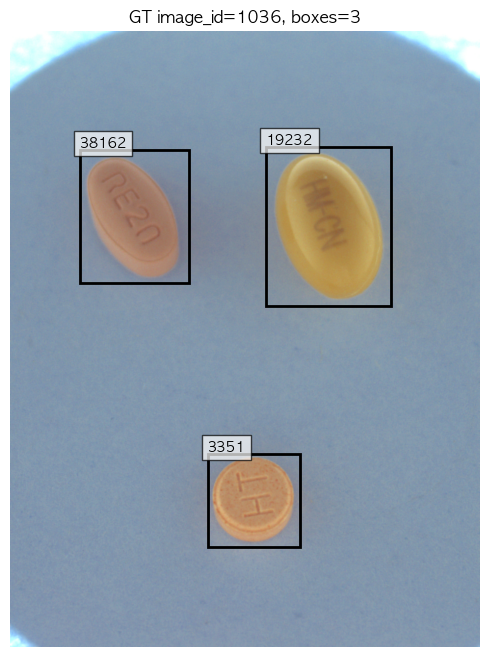

In [49]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def show_ground_truth(image_id):
    img_path = find_image_path(TRAIN_IMG_DIR, image_id)
    im = Image.open(img_path).convert("RGB")
    rows = df[df["image_id"] == image_id]

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(im)
    ax.set_title(f"GT image_id={image_id}, boxes={len(rows)}")
    ax.axis("off")

    for _, r in rows.iterrows():
        rect = patches.Rectangle(
            (r["bbox_x"], r["bbox_y"]),
            r["bbox_w"],
            r["bbox_h"],
            fill=False,
            linewidth=2,
        )
        ax.add_patch(rect)
        ax.text(
            r["bbox_x"],
            max(0, r["bbox_y"] - 5),
            str(int(r["category_id"])),
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7),
        )
    plt.show()

show_ground_truth(next(iter(train_ids)))

## 10. Create RT-DETRv2-X Custom Config

공식 RT-DETRv2 PyTorch 구조를 사용합니다.

- `MODEL_SIZE="x"`: RT-DETRv2-X, R101 backbone
- `MODEL_SIZE="l"`: RT-DETRv2-L, R50 backbone fallback
- `num_classes`: 대회 category 개수
- `remap_mscoco_category=False`: COCO 80-class remap 끄기

In [50]:
os.chdir(RTDETRV2_DIR)
print("cwd:", Path.cwd())

CONFIG_DIR = RTDETRV2_DIR / "configs"
CUSTOM_DATASET_YML = CONFIG_DIR / "dataset" / "pill_detection.yml"

dataset_yml = f'''
task: detection

evaluator:
  type: CocoEvaluator
  iou_types: ['bbox']

num_classes: {NUM_CLASSES}
remap_mscoco_category: False

train_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: {str(IMG_TRAIN_OUT)}
    ann_file: {str(ANN_DIR / "train.json")}
    return_masks: False
    transforms:
      type: Compose
      ops: ~
  shuffle: True
  num_workers: {NUM_WORKERS}
  drop_last: True
  collate_fn:
    type: BatchImageCollateFunction

val_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: {str(IMG_VAL_OUT)}
    ann_file: {str(ANN_DIR / "val.json")}
    return_masks: False
    transforms:
      type: Compose
      ops: ~
  shuffle: False
  num_workers: {NUM_WORKERS}
  drop_last: False
  collate_fn:
    type: BatchImageCollateFunction
'''

CUSTOM_DATASET_YML.write_text(dataset_yml)
print(CUSTOM_DATASET_YML.read_text())

cwd: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch

task: detection

evaluator:
  type: CocoEvaluator
  iou_types: ['bbox']

num_classes: 56
remap_mscoco_category: False

train_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pill_coco/images/train
    ann_file: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pill_coco/annotations/train.json
    return_masks: False
    transforms:
      type: Compose
      ops: ~
  shuffle: True
  num_workers: 0
  drop_last: True
  collate_fn:
    type: BatchImageCollateFunction

val_dataloader:
  type: DataLoader
  dataset:
    type: CocoDetection
    img_folder: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pill_coco/images/val
    ann_file: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pill_coco/annotations/val.json
    return_masks: False
    transforms:
      type

In [51]:
CUSTOM_MODEL_YML = CONFIG_DIR / "rtdetrv2" / f"rtdetrv2_{MODEL_SIZE}_pill.yml"

# Official RT-DETRv2-X config is based on r101vd_6x_coco.
# RT-DETRv2-L config is based on r50vd_6x_coco.
if MODEL_SIZE.lower() == "x":
    model_body = f'''
__include__: [
  '../dataset/pill_detection.yml',
  '../runtime.yml',
  './include/dataloader.yml',
  './include/optimizer.yml',
  './include/rtdetrv2_r50vd.yml',
]

output_dir: ./output/rtdetrv2_x_pill

PResNet:
  depth: 101

HybridEncoder:
  hidden_dim: 384
  dim_feedforward: 2048

RTDETRTransformerv2:
  feat_channels: [384, 384, 384]

train_dataloader:
  total_batch_size: {TOTAL_BATCH_SIZE}
  num_workers: {NUM_WORKERS}
  dataset:
    transforms:
      ops:
        - {{type: RandomPhotometricDistort, p: 0.5}}
        - {{type: RandomZoomOut, fill: 0}}
        - {{type: RandomIoUCrop, p: 0.8}}
        - {{type: SanitizeBoundingBoxes, min_size: 1}}
        - {{type: RandomHorizontalFlip}}
        - {{type: Resize, size: [{IMAGE_SIZE}, {IMAGE_SIZE}]}}
        - {{type: SanitizeBoundingBoxes, min_size: 1}}
        - {{type: ConvertPILImage, dtype: 'float32', scale: True}}
        - {{type: ConvertBoxes, fmt: 'cxcywh', normalize: True}}

val_dataloader:
  total_batch_size: {max(1, TOTAL_BATCH_SIZE)}
  num_workers: {NUM_WORKERS}
  dataset:
    transforms:
      ops:
        - {{type: Resize, size: [{IMAGE_SIZE}, {IMAGE_SIZE}]}}
        - {{type: ConvertPILImage, dtype: 'float32', scale: True}}

optimizer:
  type: AdamW
  params:
    -
      params: '^(?=.*backbone)(?!.*norm|bn).*$'
      lr: 0.000001
    -
      params: '^(?=.*(?:encoder|decoder))(?=.*(?:norm|bn)).*$'
      weight_decay: 0.
  lr: 0.0001
  betas: [0.9, 0.999]
  weight_decay: 0.0001

epoches: {EPOCHS}
use_amp: {str(USE_AMP)}
'''
elif MODEL_SIZE.lower() == "l":
    model_body = f'''
__include__: [
  '../dataset/pill_detection.yml',
  '../runtime.yml',
  './include/dataloader.yml',
  './include/optimizer.yml',
  './include/rtdetrv2_r50vd.yml',
]

output_dir: ./output/rtdetrv2_l_pill

train_dataloader:
  total_batch_size: {TOTAL_BATCH_SIZE}
  num_workers: {NUM_WORKERS}
  dataset:
    transforms:
      ops:
        - {{type: RandomPhotometricDistort, p: 0.5}}
        - {{type: RandomZoomOut, fill: 0}}
        - {{type: RandomIoUCrop, p: 0.8}}
        - {{type: SanitizeBoundingBoxes, min_size: 1}}
        - {{type: RandomHorizontalFlip}}
        - {{type: Resize, size: [{IMAGE_SIZE}, {IMAGE_SIZE}]}}
        - {{type: SanitizeBoundingBoxes, min_size: 1}}
        - {{type: ConvertPILImage, dtype: 'float32', scale: True}}
        - {{type: ConvertBoxes, fmt: 'cxcywh', normalize: True}}

val_dataloader:
  total_batch_size: {max(1, TOTAL_BATCH_SIZE)}
  num_workers: {NUM_WORKERS}
  dataset:
    transforms:
      ops:
        - {{type: Resize, size: [{IMAGE_SIZE}, {IMAGE_SIZE}]}}
        - {{type: ConvertPILImage, dtype: 'float32', scale: True}}

epoches: {EPOCHS}
use_amp: {str(USE_AMP)}
'''
else:
    raise ValueError("MODEL_SIZE must be 'x' or 'l'")

CUSTOM_MODEL_YML.write_text(model_body)
print("custom config:", CUSTOM_MODEL_YML)
print(CUSTOM_MODEL_YML.read_text())

custom config: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/configs/rtdetrv2/rtdetrv2_x_pill.yml

__include__: [
  '../dataset/pill_detection.yml',
  '../runtime.yml',
  './include/dataloader.yml',
  './include/optimizer.yml',
  './include/rtdetrv2_r50vd.yml',
]

output_dir: ./output/rtdetrv2_x_pill

PResNet:
  depth: 101

HybridEncoder:
  hidden_dim: 384
  dim_feedforward: 2048

RTDETRTransformerv2:
  feat_channels: [384, 384, 384]

train_dataloader:
  total_batch_size: 4
  num_workers: 0
  dataset:
    transforms:
      ops:
        - {type: RandomPhotometricDistort, p: 0.5}
        - {type: RandomZoomOut, fill: 0}
        - {type: RandomIoUCrop, p: 0.8}
        - {type: SanitizeBoundingBoxes, min_size: 1}
        - {type: RandomHorizontalFlip}
        - {type: Resize, size: [640, 640]}
        - {type: SanitizeBoundingBoxes, min_size: 1}
        - {type: ConvertPILImage, dtype: 'float32', scale: True}
        - {type: ConvertBoxes, fmt: 'cx

## 11. Download Pretrained Checkpoint

공식 checkpoint를 fine-tuning 시작점으로 사용합니다.

- X: `rtdetrv2_r101vd_6x_coco_from_paddle.pth`
- L: `rtdetrv2_r50vd_6x_coco_from_paddle.pth`

In [52]:
PRETRAIN_DIR = WORK_DIR / "pretrained"
PRETRAIN_DIR.mkdir(parents=True, exist_ok=True)

if MODEL_SIZE.lower() == "x":
    PRETRAINED_CKPT = PRETRAIN_DIR / "rtdetrv2_r101vd_6x_coco_from_paddle.pth"
    PRETRAINED_URL = "https://github.com/lyuwenyu/storage/releases/download/v0.1/rtdetrv2_r101vd_6x_coco_from_paddle.pth"
else:
    PRETRAINED_CKPT = PRETRAIN_DIR / "rtdetrv2_r50vd_6x_coco_from_paddle.pth"
    PRETRAINED_URL = "https://github.com/lyuwenyu/storage/releases/download/v0.1/rtdetrv2_r50vd_6x_coco_from_paddle.pth"

def download_with_tqdm(url, dst: Path):
    import urllib.request
    from tqdm.auto import tqdm

    dst.parent.mkdir(parents=True, exist_ok=True)
    with tqdm(unit="B", unit_scale=True, unit_divisor=1024, desc=dst.name) as pbar:
        def reporthook(block_num, block_size, total_size):
            if total_size > 0 and pbar.total != total_size:
                pbar.total = total_size
            downloaded = block_num * block_size
            pbar.update(max(0, downloaded - pbar.n))

        urllib.request.urlretrieve(url, dst, reporthook=reporthook)
        pbar.n = pbar.total or pbar.n
        pbar.refresh()

if not PRETRAINED_CKPT.exists():
    print("downloading:", PRETRAINED_URL)
    download_with_tqdm(PRETRAINED_URL, PRETRAINED_CKPT)
else:
    print("pretrained checkpoint exists:", PRETRAINED_CKPT)

print(PRETRAINED_CKPT, PRETRAINED_CKPT.exists(), f"{PRETRAINED_CKPT.stat().st_size / 1024**2:.1f} MB" if PRETRAINED_CKPT.exists() else "")

pretrained checkpoint exists: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pretrained/rtdetrv2_r101vd_6x_coco_from_paddle.pth
/Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pretrained/rtdetrv2_r101vd_6x_coco_from_paddle.pth True 293.5 MB


## 12. Train RT-DETRv2

OOM이 나면 아래 순서로 낮추세요.

```text
TOTAL_BATCH_SIZE=4 → 2 → 1
MODEL_SIZE="x" → "l"
IMAGE_SIZE=640 유지
```

In [53]:
import os
import re
import subprocess
import sys
from tqdm.auto import tqdm

for var in ["RANK", "LOCAL_RANK", "WORLD_SIZE", "MASTER_ADDR", "MASTER_PORT"]:
    os.environ.pop(var, None)

os.chdir(RTDETRV2_DIR)
print("cwd:", Path.cwd())

train_cmd = [
    sys.executable,
    "tools/train.py",
    "-c", str(CUSTOM_MODEL_YML),
    "-t", str(PRETRAINED_CKPT),
    "-d", TRAIN_DEVICE,
    f"--seed={RANDOM_SEED}",
    "-u", "print_freq=10",
]
if USE_AMP:
    train_cmd.append("--use-amp")

print("run:", " ".join(train_cmd))

epoch_re = re.compile(r"Epoch:\s*\[(\d+)\]\s*\[\s*(\d+)/(\d+)\]")
epoch_done_re = re.compile(r"Epoch:\s*\[(\d+)\]\s*Total time")
important_prefixes = (
    "Start training",
    "Not init distributed mode",
    "Initialized distributed mode",
    "Averaged stats:",
    "Test:",
    "Accumulating evaluation results",
    "DONE",
)
important_contains = (
    "IoU metric:",
    "Average Precision",
    "Average Recall",
    "coco_eval_bbox",
    "best_stat",
    "warning",
    "Warning",
    "ERROR",
    "Error",
    "Traceback",
)

cfg_omitted = False

def should_print_train_line(line: str):
    stripped = line.strip()
    if not stripped:
        return False
    if stripped.startswith("cfg:"):
        return False
    if stripped.startswith("Epoch:"):
        return True
    if stripped.startswith(important_prefixes):
        return True
    return any(token in stripped for token in important_contains)

epoch_bar = tqdm(total=EPOCHS, desc="epochs", unit="epoch")
iter_bar = None
iter_epoch = None
try:
    process = subprocess.Popen(
        train_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=os.environ.copy(),
    )

    assert process.stdout is not None
    for line in process.stdout:
        if line.startswith("cfg:") and not cfg_omitted:
            print("cfg: <omitted; custom YAML files were printed in the previous config cells>")
            cfg_omitted = True
        elif should_print_train_line(line):
            print(line, end="")

        match = epoch_re.search(line)
        if match:
            epoch = int(match.group(1))
            step = int(match.group(2))
            total = int(match.group(3))
            if iter_bar is None or iter_epoch != epoch:
                if iter_bar is not None:
                    iter_bar.close()
                iter_epoch = epoch
                iter_bar = tqdm(total=total, desc=f"epoch {epoch + 1}/{EPOCHS}", unit="it", leave=False)
            iter_bar.n = min(step + 1, total)
            iter_bar.refresh()

        done = epoch_done_re.search(line)
        if done:
            epoch = int(done.group(1))
            epoch_bar.n = max(epoch_bar.n, min(epoch + 1, EPOCHS))
            epoch_bar.refresh()
            if iter_bar is not None:
                iter_bar.n = iter_bar.total or iter_bar.n
                iter_bar.refresh()
                iter_bar.close()
                iter_bar = None
                iter_epoch = None

    return_code = process.wait()
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, train_cmd)
finally:
    if iter_bar is not None:
        iter_bar.close()
    epoch_bar.close()

/Users/pio/.DataAnalysis/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cwd: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch
run: /Users/pio/.DataAnalysis/bin/python tools/train.py -c /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/configs/rtdetrv2/rtdetrv2_x_pill.yml -t /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/pretrained/rtdetrv2_r101vd_6x_coco_from_paddle.pth -d mps --seed=42 -u print_freq=10


epochs:   0%|          | 0/50 [00:00<?, ?epoch/s]

Not init distributed mode.
cfg: <omitted; custom YAML files were printed in the previous config cells>
Start training
/Users/pio/.DataAnalysis/lib/python3.11/site-packages/torch/autograd/graph.py:882: UserWarning: The operator 'aten::grid_sampler_2d_backward' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at /Users/runner/work/pytorch/pytorch/aten/src/ATen/mps/MPSFallback.mm:34.)
/Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/tools/../src/solver/det_engine.py:85: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Epoch: [0]  [ 0/50]  eta: 0:01:24  lr: 0.000000  loss: 48.4320 (48.4320)  loss_vfl: 1.9036 (1.9036)  loss_bbox: 0.8828 (0.8828)  loss_giou: 0.8034 (0.8034)  loss_vfl_aux_0: 1.5605 (1.5605)  loss_bbox_aux_0: 1.0428 (1.0428)  loss_giou_aux_0: 1.0160 (1.0160)  loss_vfl_aux_1: 1.6054 (1.6054) 

Epoch: [0]  [10/50]  eta: 0:00:47  lr: 0.000000  loss: 47.6047 (47.6778)  loss_vfl: 2.8220 (2.7586)  loss_bbox: 0.3863 (0.4463)  loss_giou: 0.5041 (0.5322)  loss_vfl_aux_0: 2.1170 (2.0046)  loss_bbox_aux_0: 0.6056 (0.6655)  loss_giou_aux_0: 0.7740 (0.8009)  loss_vfl_aux_1: 2.3011 (2.2371)  loss_bbox_aux_1: 0.5404 (0.6173)  loss_giou_aux_1: 0.6794 (0.7024)  loss_vfl_aux_2: 2.5208 (2.4620)  loss_bbox_aux_2: 0.4852 (0.5376)  loss_giou_aux_2: 0.6008 (0.6025)  loss_vfl_aux_3: 2.7038 (2.6245)  loss_bbox_aux_3: 0.4938 (0.4747)  loss_giou_aux_3: 0.5517 (0.5650)  loss_vfl_aux_4: 2.7535 (2.7371)  loss_bbox_aux_4: 0.3786 (0.4449)  loss_giou_aux_4: 0.5040 (0.5343)  loss_vfl_dn_0: 2.1762 (2.1307)  loss_bbox_dn_0: 0.6411 (0.7037)  loss_giou_dn_0: 0.6926 (0.7041)  loss_vfl_dn_1: 2.5855 (2.5211)  loss_bbox_dn_1: 0.5598 (0.6016)  loss_giou_dn_1: 0.5379 (0.5586)  loss_vfl_dn_2: 2.6460 (2.5937)  loss_bbox_dn_2: 0.5746 (0.5981)  loss_giou_dn_2: 0.5708 (0.5699)  loss_vfl_dn_3: 2.6809 (2.6560)  loss_bbox_dn

...

Epoch: [49]  [30/50]  eta: 0:00:31  lr: 0.000001  loss: 6.4167 (6.7568)  loss_vfl: 0.2167 (0.2604)  loss_bbox: 0.0419 (0.0495)  loss_giou: 0.0775 (0.0920)  loss_vfl_aux_0: 0.4147 (0.5126)  loss_bbox_aux_0: 0.0563 (0.0610)  loss_giou_aux_0: 0.0939 (0.1029)  loss_vfl_aux_1: 0.3035 (0.3655)  loss_bbox_aux_1: 0.0456 (0.0481)  loss_giou_aux_1: 0.0783 (0.0837)  loss_vfl_aux_2: 0.2257 (0.3064)  loss_bbox_aux_2: 0.0403 (0.0468)  loss_giou_aux_2: 0.0750 (0.0818)  loss_vfl_aux_3: 0.2129 (0.2674)  loss_bbox_aux_3: 0.0433 (0.0494)  loss_giou_aux_3: 0.0771 (0.0919)  loss_vfl_aux_4: 0.2417 (0.2698)  loss_bbox_aux_4: 0.0421 (0.0495)  loss_giou_aux_4: 0.0776 (0.0919)  loss_vfl_dn_0: 0.5357 (0.5495)  loss_bbox_dn_0: 0.1216 (0.1221)  loss_giou_dn_0: 0.1862 (0.1971)  loss_vfl_dn_1: 0.2939 (0.3225)  loss_bbox_dn_1: 0.0525 (0.0561)  loss_giou_dn_1: 0.0878 (0.0919)  loss_vfl_dn_2: 0.2320 (0.2647)  loss_bbox_dn_2: 0.0457 (0.0493)  loss_giou_dn_2: 0.0810 (0.0825)  loss_vfl_dn_3: 0.2082 (0.2451)  loss_bbox_dn_

Epoch: [49]  [40/50]  eta: 0:00:16  lr: 0.000001  loss: 5.8947 (6.6003)  loss_vfl: 0.2076 (0.2445)  loss_bbox: 0.0427 (0.0483)  loss_giou: 0.0778 (0.0897)  loss_vfl_aux_0: 0.4409 (0.5038)  loss_bbox_aux_0: 0.0505 (0.0592)  loss_giou_aux_0: 0.0911 (0.1015)  loss_vfl_aux_1: 0.2794 (0.3447)  loss_bbox_aux_1: 0.0456 (0.0476)  loss_giou_aux_1: 0.0775 (0.0842)  loss_vfl_aux_2: 0.2348 (0.2908)  loss_bbox_aux_2: 0.0400 (0.0464)  loss_giou_aux_2: 0.0764 (0.0821)  loss_vfl_aux_3: 0.2201 (0.2583)  loss_bbox_aux_3: 0.0434 (0.0483)  loss_giou_aux_3: 0.0763 (0.0895)  loss_vfl_aux_4: 0.2259 (0.2565)  loss_bbox_aux_4: 0.0429 (0.0482)  loss_giou_aux_4: 0.0776 (0.0895)  loss_vfl_dn_0: 0.4841 (0.5406)  loss_bbox_dn_0: 0.1075 (0.1191)  loss_giou_dn_0: 0.1814 (0.1936)  loss_vfl_dn_1: 0.2553 (0.3135)  loss_bbox_dn_1: 0.0506 (0.0560)  loss_giou_dn_1: 0.0862 (0.0920)  loss_vfl_dn_2: 0.2320 (0.2582)  loss_bbox_dn_2: 0.0431 (0.0496)  loss_giou_dn_2: 0.0773 (0.0832)  loss_vfl_dn_3: 0.2135 (0.2394)  loss_bbox_dn_

epochs: 100%|██████████| 50/50 [1:12:01<00:00, 86.44s/epoch]

Epoch: [49]  [49/50]  eta: 0:00:01  lr: 0.000001  loss: 5.8841 (6.5983)  loss_vfl: 0.1891 (0.2440)  loss_bbox: 0.0368 (0.0462)  loss_giou: 0.0738 (0.0869)  loss_vfl_aux_0: 0.4698 (0.5122)  loss_bbox_aux_0: 0.0457 (0.0570)  loss_giou_aux_0: 0.0908 (0.0992)  loss_vfl_aux_1: 0.2508 (0.3480)  loss_bbox_aux_1: 0.0390 (0.0456)  loss_giou_aux_1: 0.0769 (0.0821)  loss_vfl_aux_2: 0.2303 (0.2910)  loss_bbox_aux_2: 0.0380 (0.0447)  loss_giou_aux_2: 0.0750 (0.0808)  loss_vfl_aux_3: 0.2126 (0.2598)  loss_bbox_aux_3: 0.0373 (0.0462)  loss_giou_aux_3: 0.0728 (0.0864)  loss_vfl_aux_4: 0.1998 (0.2571)  loss_bbox_aux_4: 0.0370 (0.0461)  loss_giou_aux_4: 0.0741 (0.0867)  loss_vfl_dn_0: 0.4841 (0.5475)  loss_bbox_dn_0: 0.0987 (0.1155)  loss_giou_dn_0: 0.1755 (0.1919)  loss_vfl_dn_1: 0.2553 (0.3205)  loss_bbox_dn_1: 0.0464 (0.0541)  loss_giou_dn_1: 0.0841 (0.0902)  loss_vfl_dn_2: 0.2274 (0.2608)  loss_bbox_dn_2: 0.0394 (0.0481)  loss_giou_dn_2: 0.0810 (0.0823)  loss_vfl_dn_3: 0.2123 (0.2409)  loss_bbox_dn_

epochs: 100%|██████████| 50/50 [1:12:09<00:00, 86.60s/epoch]


## 13. Find Best Checkpoint

보통 `best.pth`, `last.pth`, 또는 epoch별 checkpoint가 생성됩니다.  
없으면 output folder를 먼저 확인하세요.

In [54]:
OUTPUT_DIR = RTDETRV2_DIR / "output" / f"rtdetrv2_{MODEL_SIZE.lower()}_pill"

print("OUTPUT_DIR:", OUTPUT_DIR)
if OUTPUT_DIR.exists():
    for p in sorted(OUTPUT_DIR.glob("*")):
        print(p.name)
else:
    print("output dir does not exist yet")

ckpt_candidates = []
if OUTPUT_DIR.exists():
    preferred = ["best.pth", "ema_best.pth", "last.pth", "checkpoint.pth"]
    for name in preferred:
        p = OUTPUT_DIR / name
        if p.exists():
            ckpt_candidates.append(p)
    ckpt_candidates += sorted(OUTPUT_DIR.glob("*.pth"))

ckpt_candidates = list(dict.fromkeys(ckpt_candidates))

if not ckpt_candidates:
    raise FileNotFoundError("No checkpoint found. Check training output folder.")

BEST_CKPT = ckpt_candidates[0]
print("BEST_CKPT:", BEST_CKPT)

OUTPUT_DIR: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/output/rtdetrv2_x_pill
best.pth
checkpoint0000.pth
checkpoint0001.pth
checkpoint0002.pth
checkpoint0003.pth
checkpoint0004.pth
checkpoint0005.pth
checkpoint0006.pth
checkpoint0007.pth
checkpoint0008.pth
checkpoint0009.pth
checkpoint0010.pth
checkpoint0011.pth
checkpoint0012.pth
checkpoint0013.pth
checkpoint0014.pth
checkpoint0015.pth
checkpoint0016.pth
checkpoint0017.pth
checkpoint0018.pth
checkpoint0019.pth
checkpoint0020.pth
checkpoint0021.pth
checkpoint0022.pth
checkpoint0023.pth
checkpoint0024.pth
checkpoint0025.pth
checkpoint0026.pth
checkpoint0027.pth
checkpoint0028.pth
checkpoint0029.pth
checkpoint0030.pth
checkpoint0031.pth
checkpoint0032.pth
checkpoint0033.pth
checkpoint0034.pth
checkpoint0035.pth
checkpoint0036.pth
checkpoint0037.pth
checkpoint0038.pth
checkpoint0039.pth
checkpoint0040.pth
checkpoint0041.pth
checkpoint0042.pth
checkpoint0043.pth
checkpoint0044.pth
checkpoint004

## 14. Official Test-Only Validation

공식 evaluator로 validation 성능을 확인합니다.

In [55]:
import os
import subprocess
import sys
from tqdm.auto import tqdm

for var in ["RANK", "LOCAL_RANK", "WORLD_SIZE", "MASTER_ADDR", "MASTER_PORT"]:
    os.environ.pop(var, None)

os.chdir(RTDETRV2_DIR)
print("cwd:", Path.cwd())

test_cmd = [
    sys.executable,
    "tools/train.py",
    "-c", str(CUSTOM_MODEL_YML),
    "-r", str(BEST_CKPT),
    "-d", TRAIN_DEVICE,
    "--test-only",
]

print("run:", " ".join(test_cmd))
with tqdm(total=1, desc="official validation", unit="run") as pbar:
    process = subprocess.Popen(
        test_cmd,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
        env=os.environ.copy(),
    )
    assert process.stdout is not None
    for line in process.stdout:
        print(line, end="")
    return_code = process.wait()
    pbar.update(1)
    if return_code != 0:
        raise subprocess.CalledProcessError(return_code, test_cmd)

cwd: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch
run: /Users/pio/.DataAnalysis/bin/python tools/train.py -c /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/configs/rtdetrv2/rtdetrv2_x_pill.yml -r /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/output/rtdetrv2_x_pill/best.pth -d mps --test-only


official validation:   0%|          | 0/1 [00:00<?, ?run/s]

Not init distributed mode.
cfg:  {'task': 'detection', '_model': None, '_postprocessor': None, '_criterion': None, '_optimizer': None, '_lr_scheduler': None, '_lr_warmup_scheduler': None, '_train_dataloader': None, '_val_dataloader': None, '_ema': None, '_scaler': None, '_train_dataset': None, '_val_dataset': None, '_collate_fn': None, '_evaluator': None, '_writer': None, 'num_workers': 0, 'batch_size': None, '_train_batch_size': None, '_val_batch_size': None, '_train_shuffle': None, '_val_shuffle': None, 'resume': '/Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch/output/rtdetrv2_x_pill/best.pth', 'tuning': None, 'epoches': 50, 'last_epoch': -1, 'use_amp': False, 'use_ema': True, 'ema_decay': 0.9999, 'ema_warmups': 2000, 'sync_bn': True, 'clip_max_norm': 0.1, 'find_unused_parameters': False, 'seed': None, 'print_freq': 100, 'checkpoint_freq': 1, 'output_dir': './output/rtdetrv2_x_pill', 'summary_dir': None, 'device': 'mps', 'yaml_cfg': {'task': 'd

official validation: 100%|██████████| 1/1 [00:06<00:00,  6.96s/run]


## 15. Load Model for Custom Inference

아래 모델 로더는 validation 예측과 submission 생성을 같이 사용합니다.

In [56]:
os.chdir(RTDETRV2_DIR)
print("cwd:", Path.cwd())

import sys
import torch
import torch.nn as nn
import torchvision.transforms as T

sys.path.append(str(RTDETRV2_DIR))

from src.core import YAMLConfig

DEVICE = TRAIN_DEVICE
CONFIG_PATH = str(CUSTOM_MODEL_YML)
CKPT_PATH = str(BEST_CKPT)

cfg = YAMLConfig(CONFIG_PATH, resume=CKPT_PATH)

checkpoint = torch.load(CKPT_PATH, map_location="cpu")
if "ema" in checkpoint:
    state = checkpoint["ema"]["module"]
elif "model" in checkpoint:
    state = checkpoint["model"]
else:
    state = checkpoint

cfg.model.load_state_dict(state, strict=False)

class RTDETRv2InferenceModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.model = cfg.model.deploy()
        self.postprocessor = cfg.postprocessor.deploy()

    def forward(self, images, orig_target_sizes):
        outputs = self.model(images)
        outputs = self.postprocessor(outputs, orig_target_sizes)
        return outputs

model = RTDETRv2InferenceModel(cfg).to(DEVICE)
model.eval()

infer_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
])

with open(DATA_WORK_DIR / "idx2cat.json") as f:
    idx2cat = {int(k): int(v) for k, v in json.load(f).items()}

print("loaded model on", DEVICE)

cwd: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/RT-DETR/rtdetrv2_pytorch
Load PResNet101 state_dict
loaded model on mps


## 16. Inference Helpers

In [57]:
def get_numeric_image_id_from_path(path: Path):
    stem = path.stem
    if stem.isdigit():
        return int(stem)
    # fallback: 파일명 안 숫자 추출
    digits = "".join(ch for ch in stem if ch.isdigit())
    if digits:
        return int(digits)
    raise ValueError(f"Cannot parse numeric image_id from filename: {path.name}")

def predict_image(img_path: Path, score_thr=SCORE_THR, max_det=MAX_DET_PER_IMAGE):
    im_pil = Image.open(img_path).convert("RGB")
    img_w, img_h = im_pil.size

    orig_size = torch.tensor([[img_w, img_h]], device=DEVICE)
    im_data = infer_transform(im_pil)[None].to(DEVICE)

    with torch.no_grad():
        labels, boxes, scores = model(im_data, orig_size)

    labels = labels[0].detach().cpu()
    boxes = boxes[0].detach().cpu()
    scores = scores[0].detach().cpu()

    keep = scores > score_thr
    labels = labels[keep]
    boxes = boxes[keep]
    scores = scores[keep]

    order = torch.argsort(scores, descending=True)
    if max_det is not None:
        order = order[:max_det]

    labels = labels[order]
    boxes = boxes[order]
    scores = scores[order]

    preds = []
    for lab, box, score in zip(labels, boxes, scores):
        x1, y1, x2, y2 = box.tolist()

        x1 = max(0, min(float(x1), img_w - 1))
        y1 = max(0, min(float(y1), img_h - 1))
        x2 = max(0, min(float(x2), img_w))
        y2 = max(0, min(float(y2), img_h))

        bw = max(1.0, x2 - x1)
        bh = max(1.0, y2 - y1)

        pred_idx = int(lab.item())
        category_id = int(idx2cat.get(pred_idx, pred_idx))

        preds.append({
            "category_id": category_id,
            "category_idx": pred_idx,
            "bbox_x": x1,
            "bbox_y": y1,
            "bbox_w": bw,
            "bbox_h": bh,
            "score": float(score.item()),
        })

    return preds

## 17. Custom Validation mAP@[0.75:0.95]

대회 metric에 맞춰 IoU thresholds를 `[0.75, 0.80, 0.85, 0.90, 0.95]`로 둔 COCOeval을 돌립니다.

In [58]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval

VAL_JSON = ANN_DIR / "val.json"

def run_val_predictions():
    val_coco = COCO(str(VAL_JSON))
    image_id_to_file = {img["id"]: img["file_name"] for img in val_coco.dataset["images"]}

    coco_results = []
    for image_id, file_name in tqdm(image_id_to_file.items(), desc="val inference"):
        img_path = IMG_VAL_OUT / file_name
        preds = predict_image(img_path, score_thr=SCORE_THR, max_det=MAX_DET_PER_IMAGE)

        for p in preds:
            # COCOeval은 학습용 contiguous category_idx를 기대함
            coco_results.append({
                "image_id": int(image_id),
                "category_id": int(p["category_idx"]),
                "bbox": [
                    float(p["bbox_x"]),
                    float(p["bbox_y"]),
                    float(p["bbox_w"]),
                    float(p["bbox_h"]),
                ],
                "score": float(p["score"]),
            })

    return coco_results

val_results = run_val_predictions()
print("num val predictions:", len(val_results))

VAL_RESULT_JSON = DATA_WORK_DIR / "val_predictions.json"
with open(VAL_RESULT_JSON, "w") as f:
    json.dump(val_results, f)

coco_gt = COCO(str(VAL_JSON))
coco_dt = coco_gt.loadRes(str(VAL_RESULT_JSON))

coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.params.iouThrs = np.arange(0.75, 0.96, 0.05)
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()

# 첫 번째 stats가 지정 iouThrs 전체 평균 AP입니다.
print("Custom mAP@[0.75:0.95]:", coco_eval.stats[0])

val inference: 100%|██████████| 32/32 [00:03<00:00,  9.39it/s]

num val predictions: 128
Evaluate annotation type *bbox*
COCOeval_opt.evaluate() finished...
DONE (t=0.00s).
Accumulating evaluation results...
COCOeval_opt.accumulate() finished...
DONE (t=0.00s).
 Average Precision  (AP) @[ IoU=0.75:0.95 | area=   all | maxDets=100 ] = 0.811
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.825
 Average Precision  (AP) @[ IoU=0.75:0.95 | area= small | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75:0.95 | area=medium | maxDets=100 ] = -1.000
 Average Precision  (AP) @[ IoU=0.75:0.95 | area= large | maxDets=100 ] = 0.811
 Average Recall     (AR) @[ IoU=0.75:0.95 | area=   all | maxDets=  1 ] = 0.817
 Average Recall     (AR) @[ IoU=0.75:0.95 | area=   all | maxDets= 10 ] = 0.817
 Average Recall     (AR) @[ IoU=0.75:0.95 | area=   all | maxDets=100 ] = 0.817
 Average Recall     (AR) @[ IoU=0.75:0.95 | area= small | maxDets=100 ] = -1.00

## 18. Visualize Validation Predictions

GT와 Prediction을 나란히 확인합니다.  
bbox가 살짝이라도 헐거우면 `mAP@[0.75:0.95]`에서 점수가 녹을 수 있습니다.

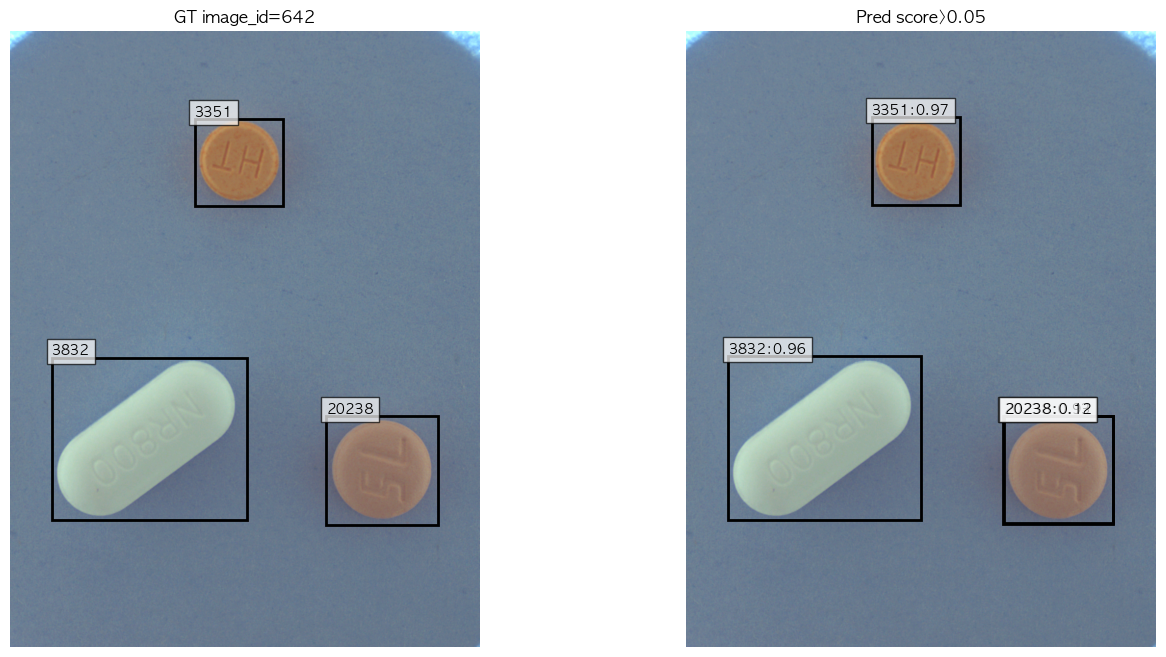

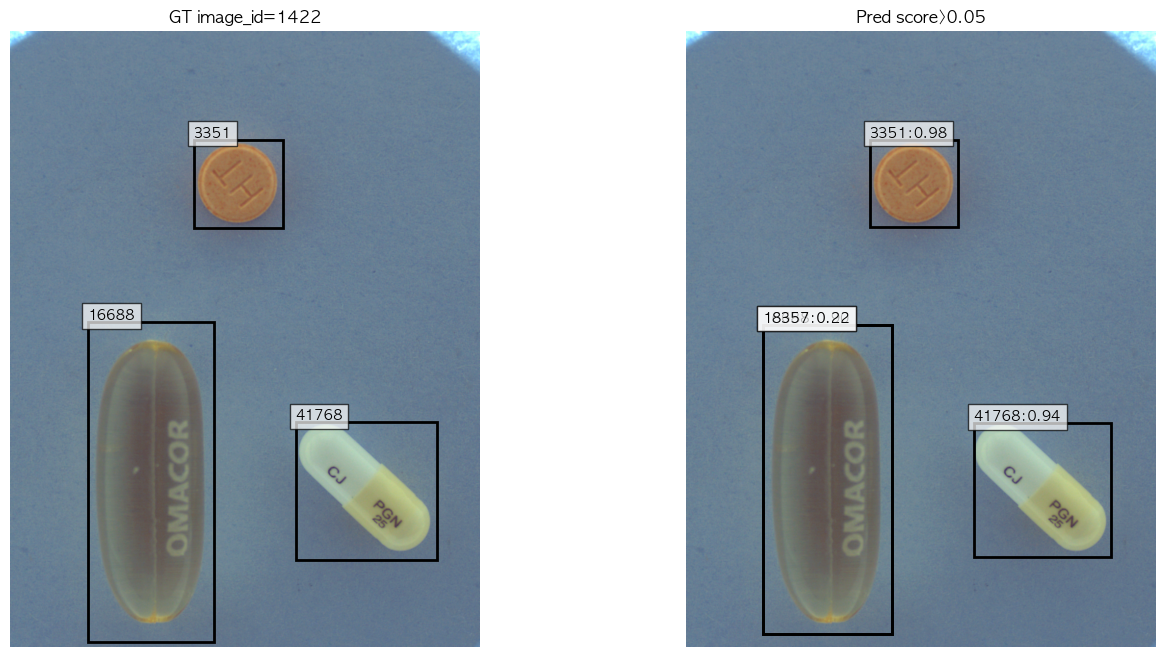

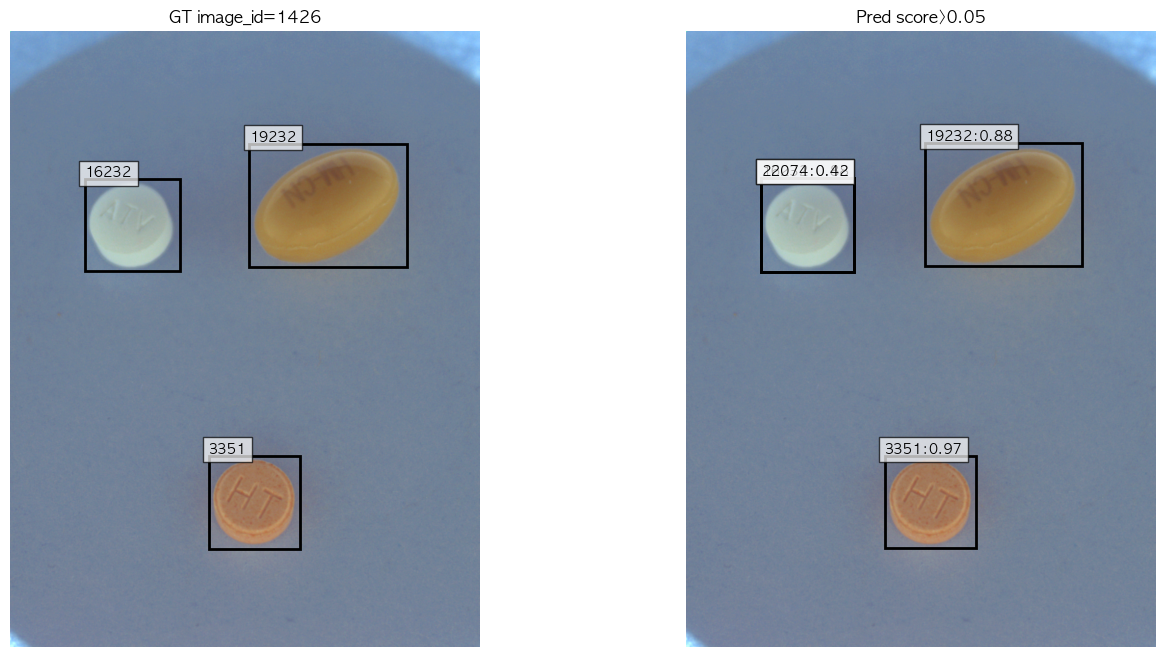

In [59]:
def show_predictions(image_id, score_thr=0.05):
    src_path = find_image_path(TRAIN_IMG_DIR, image_id)
    im = Image.open(src_path).convert("RGB")

    gt_rows = df[df["image_id"] == image_id]
    preds = predict_image(src_path, score_thr=score_thr, max_det=MAX_DET_PER_IMAGE)

    fig, axes = plt.subplots(1, 2, figsize=(16, 8))

    axes[0].imshow(im)
    axes[0].set_title(f"GT image_id={image_id}")
    axes[0].axis("off")

    for _, r in gt_rows.iterrows():
        rect = patches.Rectangle(
            (r["bbox_x"], r["bbox_y"]),
            r["bbox_w"],
            r["bbox_h"],
            fill=False,
            linewidth=2,
        )
        axes[0].add_patch(rect)
        axes[0].text(r["bbox_x"], max(0, r["bbox_y"] - 5), str(int(r["category_id"])),
                     fontsize=10, bbox=dict(facecolor="white", alpha=0.7))

    axes[1].imshow(im)
    axes[1].set_title(f"Pred score>{score_thr}")
    axes[1].axis("off")

    for p in preds:
        rect = patches.Rectangle(
            (p["bbox_x"], p["bbox_y"]),
            p["bbox_w"],
            p["bbox_h"],
            fill=False,
            linewidth=2,
        )
        axes[1].add_patch(rect)
        axes[1].text(
            p["bbox_x"],
            max(0, p["bbox_y"] - 5),
            f'{p["category_id"]}:{p["score"]:.2f}',
            fontsize=10,
            bbox=dict(facecolor="white", alpha=0.7),
        )

    plt.show()

sample_val_ids = list(val_ids)[:3]
for sid in sample_val_ids:
    show_predictions(sid, score_thr=0.05)

## 19. Test Inference → submission.csv

제출 포맷:

```text
annotation_id, image_id, category_id, bbox_x, bbox_y, bbox_w, bbox_h, score
```

`image_id`는 파일명의 숫자입니다.

In [60]:
test_paths = sorted(
    list(TEST_IMG_DIR.glob("*.jpg")) +
    list(TEST_IMG_DIR.glob("*.jpeg")) +
    list(TEST_IMG_DIR.glob("*.png")),
    key=get_numeric_image_id_from_path,
)

print("num test images:", len(test_paths))
print("sample:", [p.name for p in test_paths[:5]])

num test images: 842
sample: ['1.png', '3.png', '4.png', '5.png', '8.png']


In [61]:
submission_rows = []
annotation_id = 1

for img_path in tqdm(test_paths, desc="test inference"):
    image_id = get_numeric_image_id_from_path(img_path)
    preds = predict_image(img_path, score_thr=SCORE_THR, max_det=MAX_DET_PER_IMAGE)

    for p in preds:
        submission_rows.append({
            "annotation_id": int(annotation_id),
            "image_id": int(image_id),
            "category_id": int(p["category_id"]),
            "bbox_x": round(float(p["bbox_x"]), 2),
            "bbox_y": round(float(p["bbox_y"]), 2),
            "bbox_w": round(float(p["bbox_w"]), 2),
            "bbox_h": round(float(p["bbox_h"]), 2),
            "score": round(float(p["score"]), 6),
        })
        annotation_id += 1

submission = pd.DataFrame(
    submission_rows,
    columns=[
        "annotation_id",
        "image_id",
        "category_id",
        "bbox_x",
        "bbox_y",
        "bbox_w",
        "bbox_h",
        "score",
    ],
)

SUBMISSION_PATH = WORK_DIR / "submission.csv"
submission.to_csv(SUBMISSION_PATH, index=False)

print("saved:", SUBMISSION_PATH)
print("shape:", submission.shape)
display(submission.head(20))

test inference: 100%|██████████| 842/842 [01:20<00:00, 10.52it/s]

saved: /Users/pio/Documents/AIENGINEERCOURSE/detectionproject/working/submission.csv
shape: (3368, 8)


,annotation_id,image_id,category_id,bbox_x,bbox_y,bbox_w,bbox_h,score
0,1,1,1900,158.03,252.71,203.59,122.80,0.934008
1,2,1,27926,598.00,671.39,261.02,484.89,0.692956
2,3,1,24850,173.90,740.84,177.46,293.72,0.619791
3,4,1,29345,598.00,671.39,261.02,484.89,0.613965
4,5,3,1900,140.47,241.06,200.27,127.72,0.928152
5,6,3,27926,569.46,625.96,261.11,493.29,0.652072
6,7,3,29345,569.46,625.96,261.11,493.29,0.651957
7,8,3,24850,139.64,700.89,184.54,298.12,0.594258
8,9,4,1900,683.81,807.59,129.67,206.85,0.927673
9,10,4,29345,120.17,152.53,267.11,417.98,0.891361


## 20. Submission Sanity Checks

In [62]:
assert list(submission.columns) == [
    "annotation_id",
    "image_id",
    "category_id",
    "bbox_x",
    "bbox_y",
    "bbox_w",
    "bbox_h",
    "score",
]

assert submission["annotation_id"].is_unique
assert submission["bbox_w"].min() > 0
assert submission["bbox_h"].min() > 0
assert submission["score"].between(0, 1).all()

print("✅ submission format looks good")
print("objects per image:")
display(submission.groupby("image_id").size().describe())

✅ submission format looks good
objects per image:


count    842.0
mean       4.0
std        0.0
min        4.0
25%        4.0
50%        4.0
75%        4.0
max        4.0
dtype: float64

## 21. Next Experiments

추천 실험 순서:

```text
Exp 1. RT-DETRv2-X 640, 50 epochs
Exp 2. RT-DETRv2-X 800, 30 epochs
Exp 3. RT-DETRv2-L 800, OOM 대비
Exp 4. RT-DETRv2-X + Swin-T crop classifier
```

대회 metric이 `mAP@[0.75:0.95]`라서 우선 봐야 할 것은:

1. `Recall`: 알약을 놓치지 않는가?
2. `bbox tightness`: box가 약을 꽉 잡는가?
3. `category confusion`: box는 맞는데 class가 틀리는가?
4. `false positive`: 최대 4개 제한에서 쓸데없는 box가 끼는가?

category confusion이 크면 detector를 무한히 키우기보다, `crop → Swin-T classifier`를 붙이는 쪽이 더 깔끔합니다.